In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

plt.style.use("ICIWstyle")

In [18]:
n_dot = np.load("MGA-E-13032025_120ml-min_1atm_heated_ReactorOutlet_MS_composition.npy")
timestamps = np.load("MGA-E-13032025_120ml-min_1atm_heated_ReactorOutlet_MS_times.npy")

In [19]:
time_delta = timestamps - timestamps[0]
np.savez(
    "MGA-E-13032025_120ml-min_1atm_heated_ReactorOutlet.npz",
    n_dot=n_dot,
    time_delta=time_delta,
)


t_range = (time_delta.min(), time_delta.max())

In [20]:
t_offset = 11.5 - 1.0
t_halfperiod = 120

switching_times = np.full((20,), t_halfperiod)
switching_times = np.insert(switching_times, 0, t_offset)
switching_times = np.cumsum(switching_times)
print(switching_times)

intervals = [
    (switching_times[i], switching_times[i + 1])
    for i in range(len(switching_times) - 1)
]
print(intervals)

[  10  130  250  370  490  610  730  850  970 1090 1210 1330 1450 1570
 1690 1810 1930 2050 2170 2290 2410]
[(10, 130), (130, 250), (250, 370), (370, 490), (490, 610), (610, 730), (730, 850), (850, 970), (970, 1090), (1090, 1210), (1210, 1330), (1330, 1450), (1450, 1570), (1570, 1690), (1690, 1810), (1810, 1930), (1930, 2050), (2050, 2170), (2170, 2290), (2290, 2410)]


In [21]:
interp = scipy.interpolate.interp1d(
    time_delta,
    n_dot,
    kind="linear",
    fill_value="extrapolate",
)

In [22]:
t = np.linspace(*t_range, 1000)
n_dot_interp = interp(t)

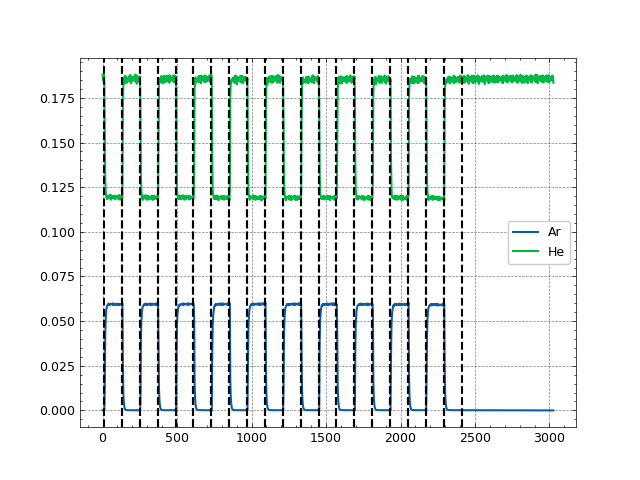

In [23]:
plt.plot(t, n_dot_interp[0], label="Ar")
plt.plot(t, n_dot_interp[1], label="He")
for interval in intervals:
    plt.axvline(interval[0], color="black", linestyle="--")
    plt.axvline(interval[1], color="black", linestyle="--")
plt.legend()

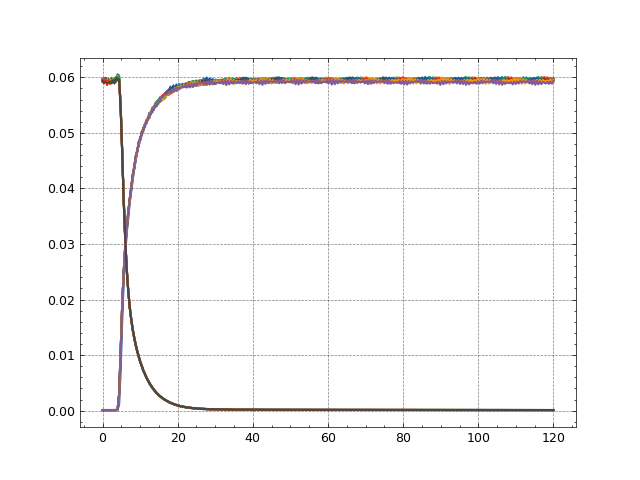

In [24]:
fig = plt.figure()
for interval in intervals:

    t = np.linspace(interval[0], interval[0] + 120, 300)

    n_dot_interp = interp(t)

    plt.plot(t - interval[0], n_dot_interp[0])